In [1]:
! pip install openai numpy scikit-learn matplotlib umap-learn datasets pacmap

zsh:1: /Volumes/Crucial X9/knowledge-gaps/.venv/bin/pip: bad interpreter: /Users/shreyanakum/Documents/knowledge-gaps/.venv/bin/python: no such file or directory

[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: pip3.9 install --upgrade pip


In [2]:
from openai import OpenAI
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import umap
from datasets import load_dataset
import pacmap
import random
random.seed(42)
import time

ds = load_dataset("camel-ai/physics")

client = OpenAI()

print(len(ds['train']))

texts = ds['train']['message_1']
print(ds['train'])

/Volumes/Crucial X9/knowledge-gaps/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


20000
Dataset({
    features: ['role_1', 'topic;', 'sub_topic', 'message_1', 'message_2'],
    num_rows: 20000
})


In [3]:
colors_type = ds['train']['topic;']

# Split into batches of 2048 and collect all embeddings
batch_size = 100  # Reduced from 2048
batches = [texts[i:i + batch_size] for i in range(0, len(texts), batch_size)]

result = []
for i, batch in enumerate(batches):
    response = client.embeddings.create(
        model="text-embedding-3-small",
        input=batch,
    )
    result.extend([np.array(item.embedding) for item in response.data])
    
    print(f"Processed batch {i+1}/{len(batches)} ({len(result)} embeddings so far)")
    time.sleep(0.5)  # Small delay to avoid rate limiting

embeddings_matrix = np.array(result)
similarity_matrix = cosine_similarity(embeddings_matrix)

# for i, text1 in enumerate(texts):
#     for j in range(i + 1, len(texts)):
#         text2 = texts[j]
#         similarity = similarity_matrix[i, j]
#         print(f"Similarity between '{text1}' and '{text2}': {similarity:.4f}")

Processed batch 1/200 (100 embeddings so far)
Processed batch 2/200 (200 embeddings so far)
Processed batch 3/200 (300 embeddings so far)
Processed batch 4/200 (400 embeddings so far)
Processed batch 5/200 (500 embeddings so far)
Processed batch 6/200 (600 embeddings so far)
Processed batch 7/200 (700 embeddings so far)
Processed batch 8/200 (800 embeddings so far)
Processed batch 9/200 (900 embeddings so far)
Processed batch 10/200 (1000 embeddings so far)
Processed batch 11/200 (1100 embeddings so far)
Processed batch 12/200 (1200 embeddings so far)
Processed batch 13/200 (1300 embeddings so far)
Processed batch 14/200 (1400 embeddings so far)
Processed batch 15/200 (1500 embeddings so far)
Processed batch 16/200 (1600 embeddings so far)
Processed batch 17/200 (1700 embeddings so far)
Processed batch 18/200 (1800 embeddings so far)
Processed batch 19/200 (1900 embeddings so far)
Processed batch 20/200 (2000 embeddings so far)
Processed batch 21/200 (2100 embeddings so far)
Processed 

### UMAP

In [4]:
# unique_types = list(set(colors_type))  # colors_level # colors_type
# color_map = {type_name: i for i, type_name in enumerate(unique_types)}
# color_values = [color_map[c] for c in colors_type]  # colors_level # colors_type

# reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=2, min_dist=0.1, init='random')
# embeddings_2d = reducer.fit_transform(embeddings_matrix)

# plt.figure(figsize=(10, 8))
# scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=color_values, s=50, alpha=0.3, cmap='tab10')

# for i, txt in enumerate(texts):
#     plt.annotate(txt[:0], (embeddings_2d[i, 0], embeddings_2d[i, 1]))

# plt.xlabel('UMAP Dimension 1')
# plt.ylabel('UMAP Dimension 2')
# plt.title('UMAP Visualization of Physics Problems Dataset on OpenAI Embedding Model')
# handles = [plt.Line2D([0], [0], marker='o', color='w', 
#                       markerfacecolor=plt.cm.tab10(color_map[t]), 
#                       markersize=10, label=t) 
#            for t in unique_types]
# plt.legend(handles=handles, title='Problem Level', bbox_to_anchor=(1.05, 1), loc='upper left')

# plt.savefig("./umap_colors_level.png")

### PaCMAP

In [5]:
np.shape(embeddings_matrix)

(20000, 1536)

Python(74745) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Running ANNOY Indexing on high-dimensional data. Nearest-neighbor search may be slow!


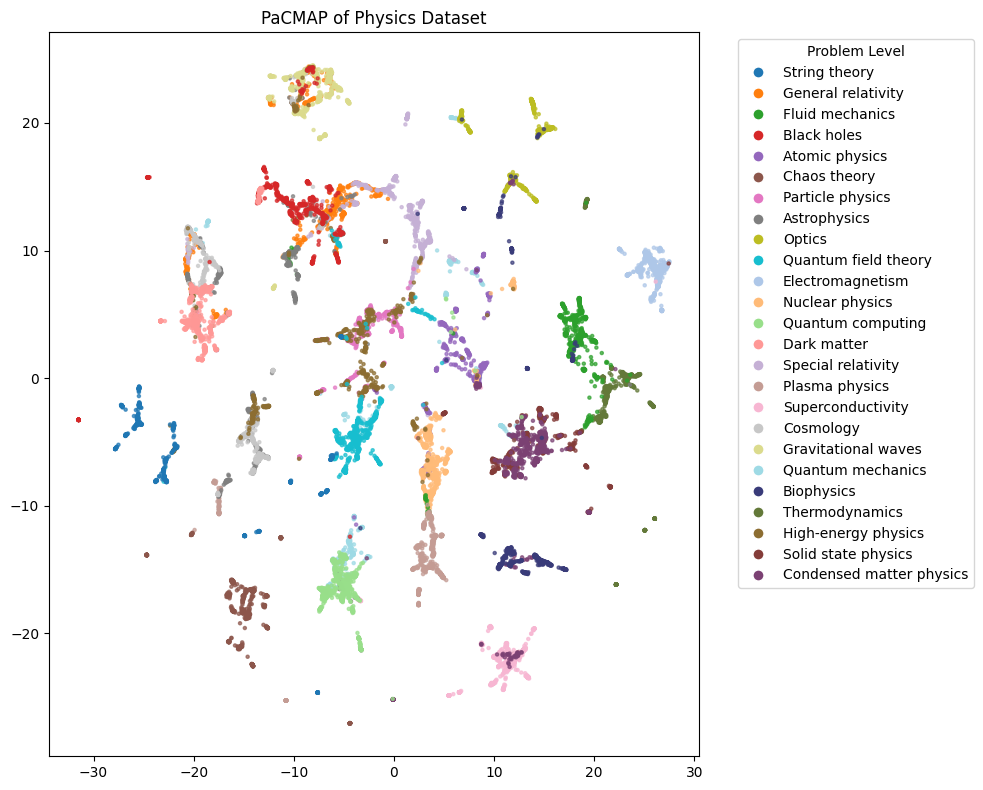

In [8]:
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import numpy as np

X = embeddings_matrix.astype(np.float32)
X = X / np.linalg.norm(X, axis=1, keepdims=True)

pca = PCA(n_components=50, random_state=42)
X_reduced = pca.fit_transform(X).astype(np.float32)

# Build neighbor graph with sklearn instead of annoy
n_neighbors = 10
nn = NearestNeighbors(n_neighbors=n_neighbors + 1, metric='euclidean', n_jobs=-1)
nn.fit(X_reduced)
distances, indices = nn.kneighbors(X_reduced)

# Strip self (first neighbor is always self)
pair_neighbors = np.column_stack([
    np.repeat(np.arange(len(X_reduced)), n_neighbors),
    indices[:, 1:].ravel()
]).astype(np.int32)

embedding = pacmap.PaCMAP(
    n_components=2,
    n_neighbors=n_neighbors,
    MN_ratio=0.5,
    FP_ratio=2.0,
    apply_pca=False,
    random_state=42
)

# Inject precomputed pairs to skip annoy entirely
embedding.pair_neighbors = pair_neighbors
X_transformed = embedding.fit_transform(X_reduced, init="pca")

# 25-color discrete palette combining Tab20 + extra distinguishable colors
TAB25 = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
    "#aec7e8", "#ffbb78", "#98df8a", "#ff9896", "#c5b0d5",
    "#c49c94", "#f7b6d2", "#c7c7c7", "#dbdb8d", "#9edae5",
    "#393b79", "#637939", "#8c6d31", "#843c39", "#7b4173"
]

unique_types = list(set(colors_type))
color_map = {t: TAB25[i % len(TAB25)] for i, t in enumerate(unique_types)}
point_colors = [color_map[t] for t in colors_type]

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.scatter(X_transformed[:, 0], X_transformed[:, 1], c=point_colors, s=5, alpha=0.7)

handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=color_map[t],
               markersize=8, label=t)
    for t in unique_types
]
ax.legend(handles=handles, title="Problem Level", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_title("PaCMAP of Physics Dataset")
plt.tight_layout()
plt.show()